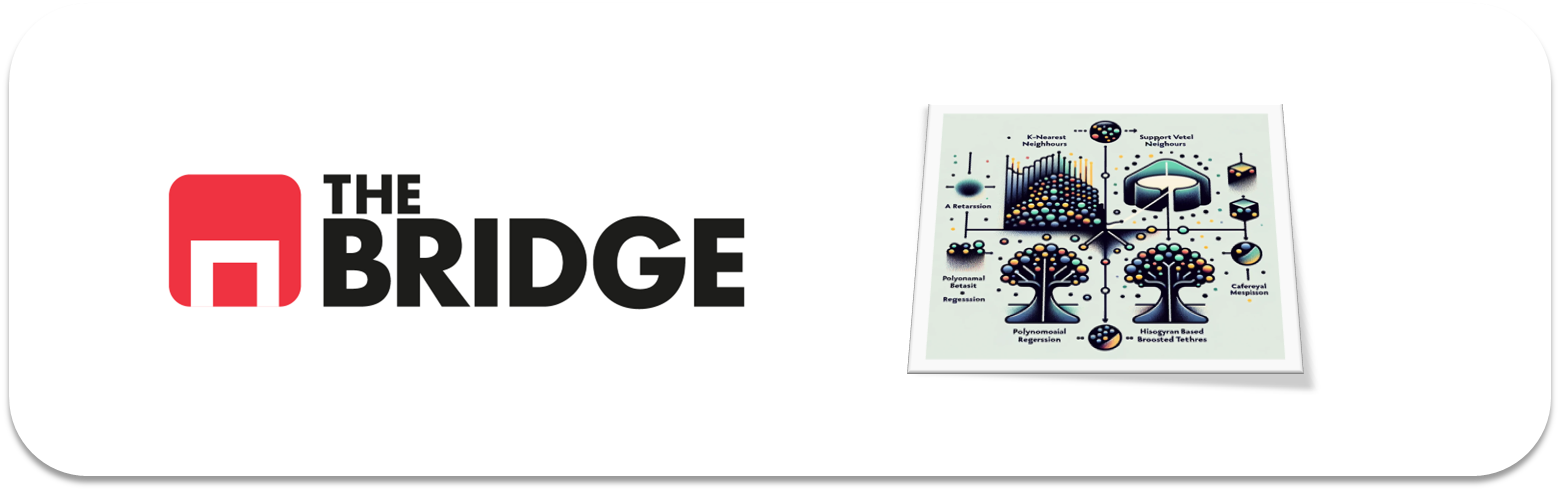

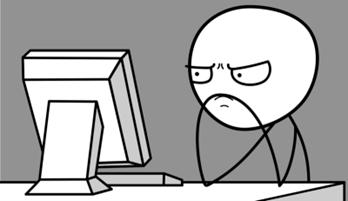

Para ejercitarte y afianzar lo aprendido sobre **Otros Modelos de aprendizaje supervisado**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
pd.options.mode.copy_on_write =True




## PARTE 1. KNN

En la primera parte  vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating (ojo, no el sentimiento), en función del sentimiento del comentario y su valor y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

### Ejercicio 1

Lee el archivo de entrada "reviews_sentiment.csv" y carga su contenido en un dataframe. Muestras sus primeras líneas, su información general y define una variable "target" asignándole el nombre de la columna que contenga el target del problema. 

In [2]:
df= pd.read_csv("./data/reviews_sentiment.csv", sep= ";")
df

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784
...,...,...,...,...,...,...,...
252,Muy buena aplicacion,Muy buena genial,3,positive,positive,5,2.814818
253,Buena,Genial,1,positive,positive,5,2.924393
254,Wuau,Genial,1,positive,positive,5,2.924393
255,Muy buena,Genial,1,positive,positive,5,2.924393


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    object 
 1   Review Text     257 non-null    object 
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    object 
 4   textSentiment   257 non-null    object 
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 14.2+ KB


In [4]:
import toolbox_ML as tool
print(tool.describe_df(df))

                 data_type valores_nulos valores_unicos cardinalidad_ptg
Review Title    categorica           0.0            186            72.37
Review Text     categorica           0.0            241            93.77
wordcount         numerica           0.0             42            16.34
titleSentiment  categorica          10.1              2             0.78
textSentiment   categorica           0.0              2             0.78
Star Rating       numerica           0.0              5             1.95
sentimentValue    numerica           0.0            241            93.77


In [5]:
# Contar nulos por columna
print(df.isnull().sum())

Review Title       0
Review Text        0
wordcount          0
titleSentiment    26
textSentiment      0
Star Rating        0
sentimentValue     0
dtype: int64


In [6]:
df.columns = df.columns.str.lower().str.replace(" " , "_")

In [7]:
df.columns

Index(['review_title', 'review_text', 'wordcount', 'titlesentiment',
       'textsentiment', 'star_rating', 'sentimentvalue'],
      dtype='object')

In [8]:
target = "star_rating"

### Ejericicio 2

Muestra la distribución del target y coméntala brevemente.

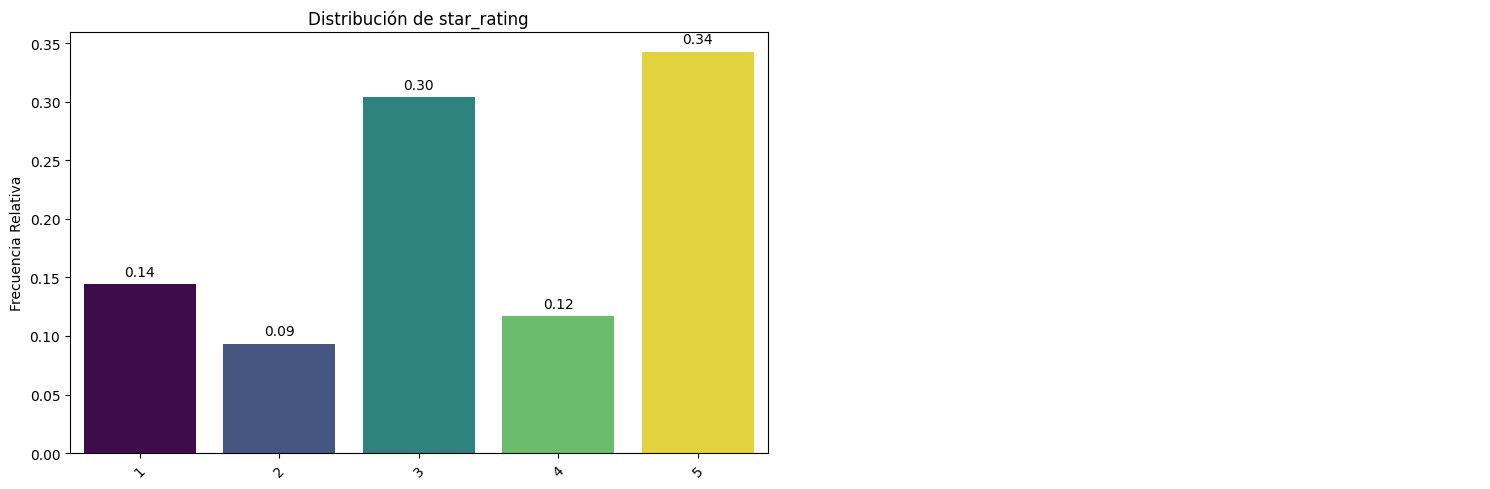

In [9]:
import bootcampviztools as bt
bt.pinta_distribucion_categoricas(df, [target], mostrar_valores= True, relativa= True)

El ranking, el target, está compuesto por cinco valores del uno al cinco. Donde 1 es la menor valoración y 5 la mayor. Hay desequilibrio entre dos grupos de valores, que a su vez están equilibrados dentro del grupo; por un lado 1, 2 y 4 con cantidades entre 0.09% y 0.14%, y por el otro lado las valoraciones 3 y 5 con cantidad de 0.30% y 0.34%.

### Ejercicio 3

Deshazte de la columna "titleSentiment" que tiene nulos y no vamos a emplearla.

In [10]:
df = df.drop("titlesentiment", axis=1)
df.columns

Index(['review_title', 'review_text', 'wordcount', 'textsentiment',
       'star_rating', 'sentimentvalue'],
      dtype='object')

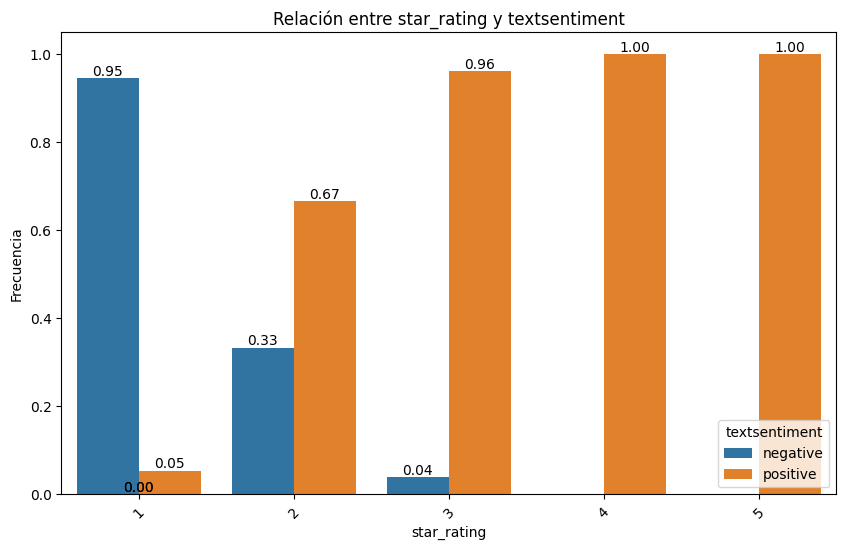

In [11]:
bt.plot_categorical_relationship_fin(df,"star_rating", "textsentiment", relative_freq= True, show_values= True)

### Ejercicio 4

Haz el split en train y test.

In [12]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, stratify= df["star_rating"], random_state=42)

# A stratify no se le puede pasar una lista de columnas, hay que combinar las columnas en una nueva.

In [13]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 8 to 168
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   review_title    205 non-null    object 
 1   review_text     205 non-null    object 
 2   wordcount       205 non-null    int64  
 3   textsentiment   205 non-null    object 
 4   star_rating     205 non-null    int64  
 5   sentimentvalue  205 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 11.2+ KB


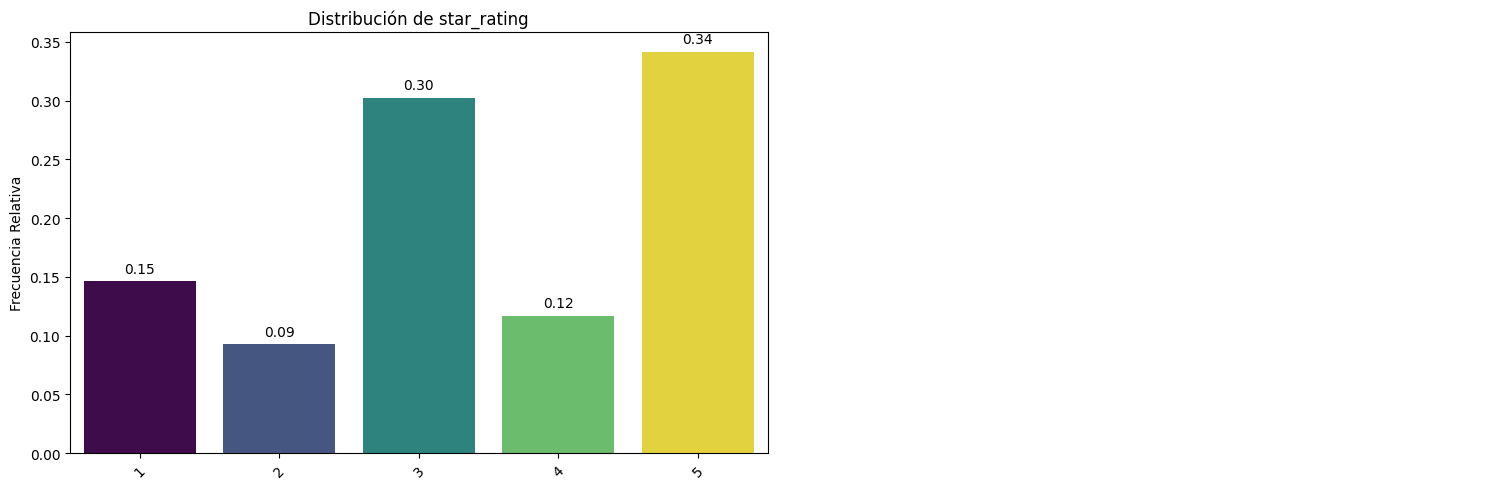

In [14]:
bt.pinta_distribucion_categoricas(train_set, [target], mostrar_valores= True, relativa= True)

### Ejercicio 5

Muestra la descripción de las variables que consideres numéricas (justificando tu elección) y sus histogramas. ¿Hay que aplicar alguna transformación o tratamiento? (Recuerda que vamos a emplear un KNN)

In [15]:
print(tool.describe_df(train_set))

                 data_type valores_nulos valores_unicos cardinalidad_ptg
review_title    categorica           0.0            158            77.07
review_text     categorica           0.0            195            95.12
wordcount         numerica           0.0             40            19.51
textsentiment   categorica           0.0              2             0.98
star_rating       numerica           0.0              5             2.44
sentimentvalue    numerica           0.0            195            95.12


In [16]:
train_set.columns

Index(['review_title', 'review_text', 'wordcount', 'textsentiment',
       'star_rating', 'sentimentvalue'],
      dtype='object')

Elijo como numéricas 'wordcount' y 'sentimentvalue' porque son tipo numéricas y por su alta cardinalidad.

In [17]:
print(train_set[['wordcount', 'sentimentvalue']].describe())

        wordcount  sentimentvalue
count  205.000000      205.000000
mean    11.560976        0.363753
std     13.768479        0.857533
min      1.000000       -2.276469
25%      3.000000       -0.116132
50%      7.000000        0.246869
75%     16.000000        0.794211
max    103.000000        3.264579


In [18]:
print(train_set["sentimentvalue"].unique)

<bound method Series.unique of 8     -0.765284
70    -0.213092
16    -1.104469
84    -0.406623
33    -0.642228
         ...   
154    0.870911
67    -0.139861
130    0.107111
51    -0.083467
168    0.462592
Name: sentimentvalue, Length: 205, dtype: float64>


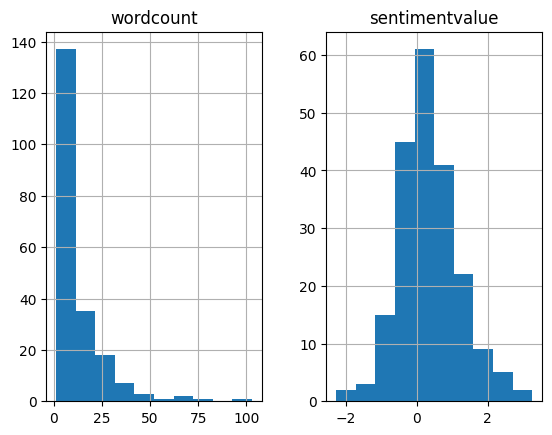

In [19]:
train_set[['wordcount', 'sentimentvalue']].hist();

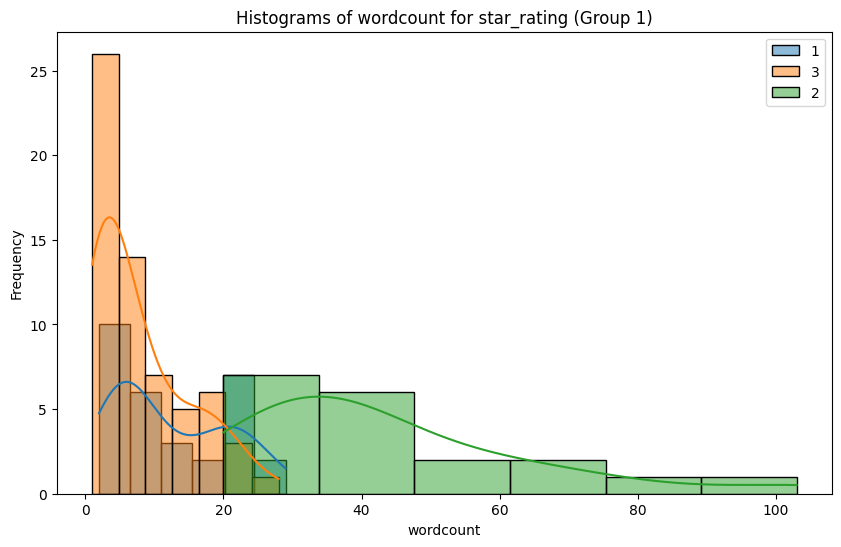

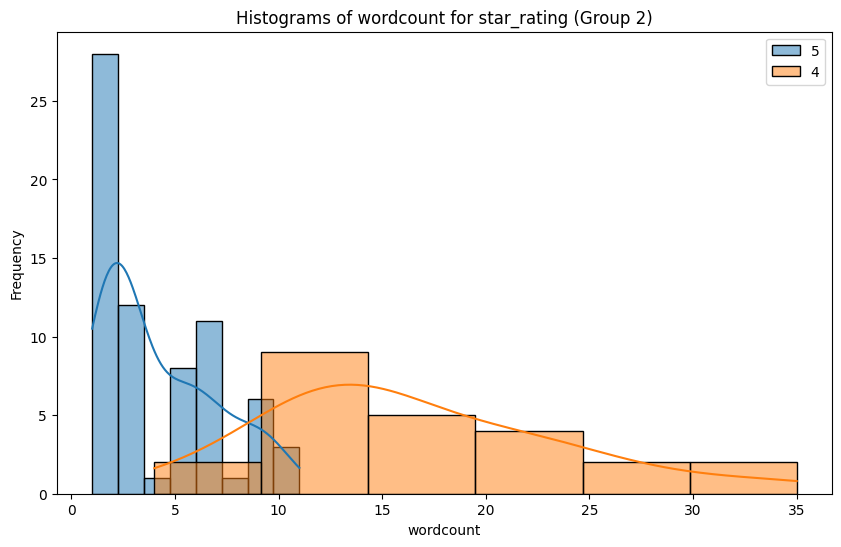

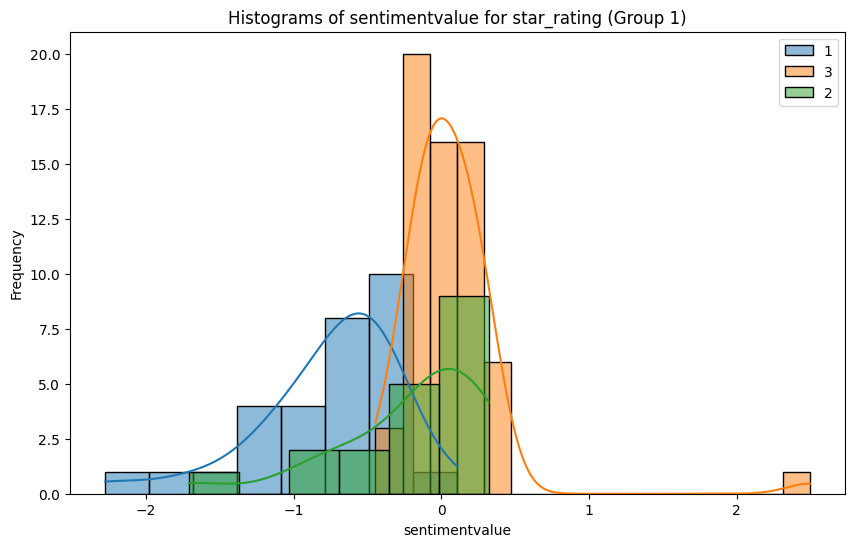

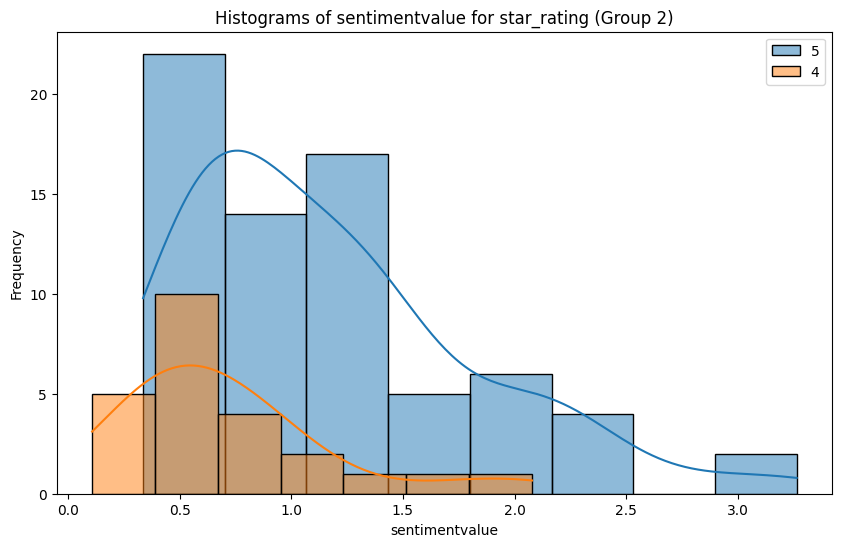

In [20]:
for col in train_set[['wordcount', 'sentimentvalue']]:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 3)

In [21]:
train_set.columns

Index(['review_title', 'review_text', 'wordcount', 'textsentiment',
       'star_rating', 'sentimentvalue'],
      dtype='object')

### Ejercicio 6

Muestra la distribución frecuencial de las variables que consideres categóricas. ¿Habrías que hacerles algún tipo de tratamiento?

Según el enunciado "El objetivo es montar un algoritmo de clasificación que prediga el rating (ojo, no el sentimiento), en función del sentimiento del comentario y su valor y la cantidad de palabras empleadas en el mismo." nos quedamos como categóricas con : textsentiment (que además es binaría).

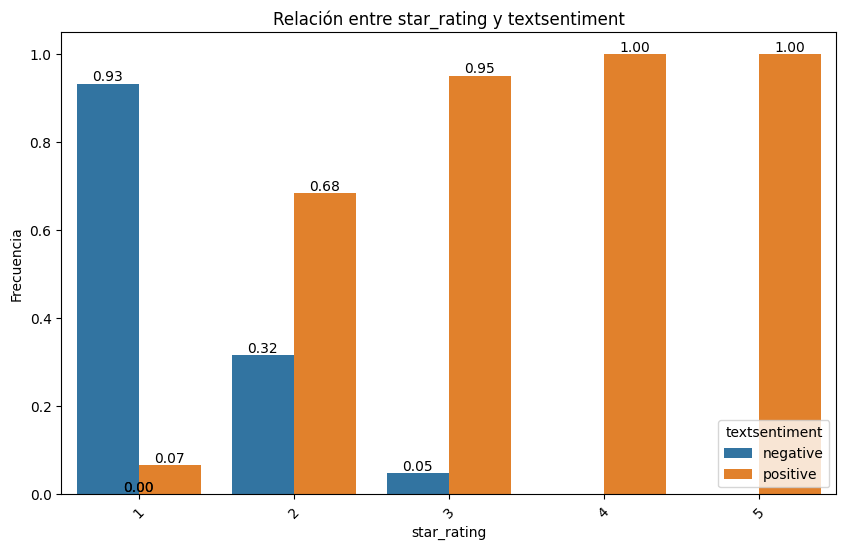

In [22]:
bt.plot_categorical_relationship_fin(train_set, target, "textsentiment", relative_freq= True, show_values= True)

In [23]:
features_cat = "textsentiment"

In [24]:
features_num = 'wordcount', 'sentimentvalue'

### Ejercicio 7

En un modelado completo habríamos comprobado la relación entre las features y el target, para estos ejercicios, las vamos a incluir sí o si. Haz el tratamiento de features, haciendo la conversión ordinal de la binaria (usa 1 para positive y 0 para negative) y aplicando el escalado que creas más conveniente en consecuencia para las numéricas

In [25]:
train_set[features_cat] = train_set[features_cat].map({"positive":1, "negative": 0})
print(train_set[features_cat].value_counts())
test_set[features_cat] = test_set[features_cat].map({"positive":1, "negative": 0})
print(test_set[features_cat].value_counts())

textsentiment
1    168
0     37
Name: count, dtype: int64
textsentiment
1    43
0     9
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_set[['wordcount', 'sentimentvalue']] =pd.DataFrame(scaler.fit_transform(train_set[['wordcount', 'sentimentvalue']]), columns=['wordcount', 'sentimentvalue'], index= train_set.index)
test_set[['wordcount', 'sentimentvalue']] = pd.DataFrame(
    scaler.transform(test_set[['wordcount', 'sentimentvalue']]), 
    columns=['wordcount', 'sentimentvalue'], 
    index=test_set.index)
# Lo importante es que todas las características contribuyan equitativamente al cálculo de distancia.
# ¿Por qué escalar ambas? KNN usa distancias para clasificar, 
# y las características con mayor rango numérico dominarán el cálculo de distancia.
# Si no escalas ambas: Los cambios en wordcount (que varía hasta 140) tendrán mucho más peso
# que los cambios en sentimentvalue (que varía solo ~5 unidades)
# El modelo ignoraría prácticamente sentimentvalue

### Ejercicio 8

Crea el juego X,y de train y test. Carga el modelo, instancialo con un k=5 para empezar y entrénalo.

In [27]:
train_set.columns

Index(['review_title', 'review_text', 'wordcount', 'textsentiment',
       'star_rating', 'sentimentvalue'],
      dtype='object')

In [28]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 8 to 168
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   review_title    205 non-null    object 
 1   review_text     205 non-null    object 
 2   wordcount       205 non-null    float64
 3   textsentiment   205 non-null    int64  
 4   star_rating     205 non-null    int64  
 5   sentimentvalue  205 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 11.2+ KB


In [29]:
features_num =list(features_num)
print(features_num)

['wordcount', 'sentimentvalue']


In [30]:
print(train_set[features_num].describe())

          wordcount  sentimentvalue
count  2.050000e+02    2.050000e+02
mean   2.599547e-17    4.332578e-17
std    1.002448e+00    1.002448e+00
min   -7.689178e-01   -3.086395e+00
25%   -6.233029e-01   -5.609803e-01
50%   -3.320730e-01   -1.366363e-01
75%    3.231941e-01    5.032015e-01
max    6.657443e+00    3.391039e+00


In [31]:
X_train = pd.concat([train_set[features_cat], train_set[features_num]], axis=1)
y_train = train_set[target]
X_test = pd.concat([test_set[features_cat], test_set[features_num]], axis=1)
y_test = test_set[target]

In [32]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(205, 3)
(205,)
(52, 3)
(52,)


In [33]:
print(type(y_train), y_train.info())

<class 'pandas.core.series.Series'>
Index: 205 entries, 8 to 168
Series name: star_rating
Non-Null Count  Dtype
--------------  -----
205 non-null    int64
dtypes: int64(1)
memory usage: 3.2 KB
<class 'pandas.core.series.Series'> None


In [34]:
print(type(X_train), X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 8 to 168
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   textsentiment   205 non-null    int64  
 1   wordcount       205 non-null    float64
 2   sentimentvalue  205 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 6.4 KB
<class 'pandas.core.frame.DataFrame'> None


In [35]:
print(train_set["textsentiment"].value_counts())

textsentiment
1    168
0     37
Name: count, dtype: int64


In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)  # Prepara el calculo de vectores


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Ejercicio 9

Evalúalo contra el propio train y contra test, ¿qué puedes decir de los resultados?

In [37]:
X_train_copia = X_train.copy()

In [41]:
prediccion = knn.predict(X_train)
X_train_copia["predicción"]= prediccion
X_train_copia

,textsentiment,wordcount,sentimentvalue,predicción
8,0,0.687231,-1.319833,1
70,1,-0.768918,-0.674326,3
16,0,1.051269,-1.716337,1
84,0,1.196884,-0.900562,3
33,0,3.745145,-1.175983,2
...,...,...,...,...
154,1,1.342499,0.592863,4
67,1,-0.768918,-0.588719,3
130,1,-0.332073,-0.300012,3
51,1,-0.768918,-0.522796,3


In [42]:
print(X_train_copia["predicción"].value_counts(),"\n", y_train.value_counts())

predicción
5    72
3    66
1    30
2    20
4    17
Name: count, dtype: int64 
 star_rating
5    70
3    62
1    30
4    24
2    19
Name: count, dtype: int64


In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accu_train = accuracy_score(y_train, prediccion)

print("=== EVALUACIÓN EN TRAIN ===")
print(f"Accuracy: {accu_train:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_train, prediccion))
print("\nMatriz de confusión:")
print(confusion_matrix(y_train, prediccion))

=== EVALUACIÓN EN TRAIN ===
Accuracy: 0.9024

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.93      0.93      0.93        30
           2       0.85      0.89      0.87        19
           3       0.88      0.94      0.91        62
           4       0.88      0.62      0.73        24
           5       0.93      0.96      0.94        70

    accuracy                           0.90       205
   macro avg       0.90      0.87      0.88       205
weighted avg       0.90      0.90      0.90       205


Matriz de confusión:
[[28  1  1  0  0]
 [ 1 17  1  0  0]
 [ 1  0 58  1  2]
 [ 0  2  4 15  3]
 [ 0  0  2  1 67]]


In [44]:
X_test_copia = X_test.copy()

In [45]:
prediccion_test = knn.predict(X_test)
X_test_copia["predicción"]= prediccion_test
X_test_copia


,textsentiment,wordcount,sentimentvalue,predicción
91,1,-0.477688,-0.419589,3
229,1,-0.186458,1.227406,5
79,0,0.104772,-0.832889,1
95,1,0.031964,-0.378585,3
14,0,0.177579,-1.691555,1
243,1,-0.332073,1.977703,5
194,1,-0.404881,0.483777,5
143,1,1.124076,-0.006614,4
128,1,-0.696110,1.990255,5
18,0,-0.477688,-1.916168,1


In [46]:
accu_test = accuracy_score(y_test, prediccion_test)

print("=== EVALUACIÓN EN TEST ===")
print(f"Accuracy: {accu_test:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, prediccion_test))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, prediccion_test))

=== EVALUACIÓN EN TEST ===
Accuracy: 0.8846

Reporte de clasificación:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      0.80      0.89         5
           3       0.82      0.88      0.85        16
           4       0.83      0.83      0.83         6
           5       0.89      0.89      0.89        18

    accuracy                           0.88        52
   macro avg       0.91      0.88      0.89        52
weighted avg       0.89      0.88      0.89        52


Matriz de confusión:
[[ 7  0  0  0  0]
 [ 0  4  0  1  0]
 [ 0  0 14  0  2]
 [ 0  0  1  5  0]
 [ 0  0  2  0 16]]


El modelo KNN con k=5 es sólido y confiable: Generaliza bien (poca diferencia train-test).
Accuracy cercana al 90% en ambos conjuntos. Sin señales de overfitting.

### Ejercicio 10

Vamos a "ajustar a mano" el valor de K, probando diferentes valores entre 1 y 20. Para ello haz un bucle que cambie el valor de K y obtenga mediante validación cruzada el valor del "balanced accuracy" para cada "modelo" y se quede con el k que mejor métrica obtenga. Luego entrena un modelo para ese k y evalúalo contra el target.

In [ ]:
from sklearn.model_selection import cross_val_score

metricas_cv = {}  # Todas las métricas de la validación cruzada, como cv= 5, nos da 5 valores.
valores = [] # Una lista con las medias de cada grupo de 5 valores.
for valor in range(1,21,1):  # no arange
    # print(f"Probando k = {valor}") ---> Está bien, pero da muchas lineas de salida.
    knn = KNeighborsClassifier(n_neighbors= valor)
     # entrenamiento = knn.fit(X_train, y_train) --> no es necesario, cross_val_score ya hace el fit.
    
    scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring= "balanced_accuracy")
    metricas_cv[valor] =scores
    valores.append(np.mean(scores))
    # print(f"Balanced accuracy promedio: {np.mean(scores):.4f}") ---> Está bien, pero da muchas lineas de salida.
    
ganador = list(metricas_cv.keys())[np.argmax(valores)]   # Tiene que estar fuera del bucle
print(f"El k ganador es {ganador}, con un balanced accuracy de {max(valores):.4f}")
   
# Como dice el enunciado, tenemos que entrenar con el mejor k.   
knn_final = KNeighborsClassifier(n_neighbors= ganador)
knn_final.fit(X_train, y_train)
predic = knn_final.predict(X_test)
print("Reporte de clasificación: ", "\n",classification_report(y_test, predic))




El k ganador es 4, con un balanced accuracy de 0.8414
Reporte de clasificación:  
               precision    recall  f1-score   support

           1       0.88      1.00      0.93         7
           2       0.80      0.80      0.80         5
           3       0.82      0.88      0.85        16
           4       1.00      0.83      0.91         6
           5       0.94      0.89      0.91        18

    accuracy                           0.88        52
   macro avg       0.89      0.88      0.88        52
weighted avg       0.89      0.88      0.89        52



In [51]:
metricas_cv

{1: array([0.82527473, 0.86065934, 0.84571429, 0.74809524, 0.69333333]),
 2: array([0.8456044 , 0.84637363, 0.84142857, 0.83809524, 0.69666667]),
 3: array([0.77637363, 0.823663  , 0.81571429, 0.8547619 , 0.81      ]),
 4: array([0.77637363, 0.87904762, 0.85571429, 0.90238095, 0.79333333]),
 5: array([0.72637363, 0.85333333, 0.75904762, 0.76809524, 0.86      ]),
 6: array([0.72637363, 0.87904762, 0.79904762, 0.84809524, 0.79333333]),
 7: array([0.72637363, 0.87904762, 0.75904762, 0.80809524, 0.77      ]),
 8: array([0.74065934, 0.87904762, 0.81571429, 0.76809524, 0.75333333]),
 9: array([0.72637363, 0.87904762, 0.79      , 0.72809524, 0.77      ]),
 10: array([0.72637363, 0.87904762, 0.81571429, 0.72809524, 0.77      ]),
 11: array([0.67637363, 0.87904762, 0.77571429, 0.72809524, 0.73666667]),
 12: array([0.74065934, 0.85333333, 0.77571429, 0.72809524, 0.73666667]),
 13: array([0.67637363, 0.83904762, 0.79      , 0.72809524, 0.73666667]),
 14: array([0.69065934, 0.87904762, 0.79      ,

In [52]:
valores

[np.float64(0.7946153846153845),
 np.float64(0.8136336996336995),
 np.float64(0.816102564102564),
 np.float64(0.8413699633699634),
 np.float64(0.7933699633699633),
 np.float64(0.8091794871794871),
 np.float64(0.7885128205128205),
 np.float64(0.7913699633699633),
 np.float64(0.7787032967032966),
 np.float64(0.7838461538461539),
 np.float64(0.7591794871794872),
 np.float64(0.766893772893773),
 np.float64(0.75403663003663),
 np.float64(0.7548937728937728),
 np.float64(0.7568937728937729),
 np.float64(0.7548937728937728),
 np.float64(0.7568937728937729),
 np.float64(0.7517509157509157),
 np.float64(0.7488937728937729),
 np.float64(0.7388937728937728)]

In [ ]:
# list(metricas_cv.keys())[np.argmax(valores)] 
# np.argmax(valores) --> nos da el índice del valor máximo en la lista valores
# metricas_cv.keys() --> claves del diccionario (en este caso los valores de k),
# list() --> Convierte a lista (los valores de k) para poder usar indexación [índice]
# [] --> Accede en la lista a la posición que determinamos entre corchetes

### Ejercicio 11

Repasa la ficha de KNN o la documentación de sklearn y, usando un grid y una estrategia completa (GridSearch), busca la mejor combinación de k y weights que puedas, empleando de nuevo "balanced_accuracy" como métrica.

In [55]:
from sklearn.model_selection import GridSearchCV
params_grid = {
    "n_neighbors": [2, 4, 5, 7, 27],
    "weights": ['distance', None],
    "algorithm" : ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "metric": ['manhattan','chebyshev', 'minkowski'],
}
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn,
                       param_grid= params_grid,
                       cv = 5,
                       scoring = "balanced_accuracy",
                       n_jobs = -1)

knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'ball_tree', ...], 'metric': ['manhattan', 'chebyshev', ...], 'n_neighbors': [2, 4, ...], 'weights': ['distance', None]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [ ]:
knn_grid.best_params_

{'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 4, 'weights': None}

In [65]:
predi = knn_grid.best_estimator_.predict(X_test)

print(classification_report(y_test, predi))

              precision    recall  f1-score   support

           1       0.88      1.00      0.93         7
           2       0.80      0.80      0.80         5
           3       0.88      0.88      0.88        16
           4       1.00      1.00      1.00         6
           5       0.94      0.89      0.91        18

    accuracy                           0.90        52
   macro avg       0.90      0.91      0.90        52
weighted avg       0.91      0.90      0.90        52

